## Notebook 01 — Data Preprocessing

### Purpose
This notebook loads, cleans, and prepares the raw Brent crude oil 
futures dataset for modelling.

Only the daily closing Price column is used as both input and target. 
All other columns (Open, High, Low, Vol., Change %) are dropped. This 
ensures performance differences between models reflect architecture 
alone, not input features (Paul, Chacko and Bhattacharjee, 2025).

code
python
df = load_and_clean(cfg)
print(df.shape)
print(df.dtypes)
print(df.head(3))
print(df.describe().round(2))
### Data source
Investing.com (2024) Brent Crude Oil Futures — Historical Data.
6,422 daily observations: 4 January 2000 to 31 December 2024.

### Outputs
| File | Path |
|------|------|
| brent_processed.csv | data/processed/ |
| minmax_scaler.pkl | data/processed/ |

In [22]:
import yaml
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import MinMaxScaler

PROJECT_ROOT = r"C:\ml-vs-dl-models-for-brent-crude-oil-price-forecasting\UcheNlemadim-ml-vs-dl-models-for-brent-crude-oil-price-forecasting"
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
print("Working directory:", os.getcwd())

from src.preprocessing import load_config, load_and_clean, split_data
cfg = load_config("configs/config.yaml")
print("Config loaded successfully")

Working directory: C:\ml-vs-dl-models-for-brent-crude-oil-price-forecasting\UcheNlemadim-ml-vs-dl-models-for-brent-crude-oil-price-forecasting
Config loaded successfully


In [23]:
df = load_and_clean(cfg)
print(df.shape)
print(df.head(3))
print(df.describe().round(2))

Total rows retained: 6422; Date range: 2000-01-04 to 2024-12-31; Duplicates removed: 0
(6422, 1)
            Price
Date             
2000-01-04  24.39
2000-01-05  23.73
2000-01-06  23.62
         Price
count  6422.00
mean     67.21
std      28.54
min      17.68
25%      45.10
50%      66.05
75%      85.80
max     146.08


In [24]:
print("Missing values:", df.isnull().sum().values[0])
train, val, test = split_data(df, cfg)

assert len(train) == cfg["splits"]["train_rows"], "Train size mismatch"
assert len(val)   == cfg["splits"]["val_rows"],   "Val size mismatch"
assert len(test)  == cfg["splits"]["test_rows"],  "Test size mismatch"

print("\nSplit verification passed.")
for name, split in [("Train", train), ("Val", val), ("Test", test)]:
    print(f"{name}: {len(split):,} rows  "
          f"{split.index.min().date()} to {split.index.max().date()}")

Missing values: 0
Train shape: (5389, 1); Val shape: (517, 1); Test shape: (516, 1)

Split verification passed.
Train: 5,389 rows  2000-01-04 to 2020-12-31
Val: 517 rows  2021-01-04 to 2022-12-30
Test: 516 rows  2023-01-03 to 2024-12-31


In [28]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train.values.reshape(-1, 1))

os.makedirs("data/processed", exist_ok=True)
joblib.dump(scaler, cfg["data"]["scaler_path"])

print(f"Scaler fitted on train only.")
print(f"Train Price range: [{scaler.data_min_[0]:.2f}, {scaler.data_max_[0]:.2f}]")
print(f"Scaler saved to: {cfg['data']['scaler_path']}")

Scaler fitted on train only.
Train Price range: [17.68, 146.08]
Scaler saved to: data/processed/minmax_scaler.pkl


In [29]:
df.to_csv(cfg["data"]["processed_path"])
print(f"Processed data saved to: {cfg['data']['processed_path']}")

import pathlib
saved = pathlib.Path(cfg["data"]["processed_path"])
print(f"File exists: {saved.exists()}")
print(f"File size: {saved.stat().st_size / 1024:.1f} KB")

Processed data saved to: data/processed/brent_processed.csv
File exists: True
File size: 113.4 KB


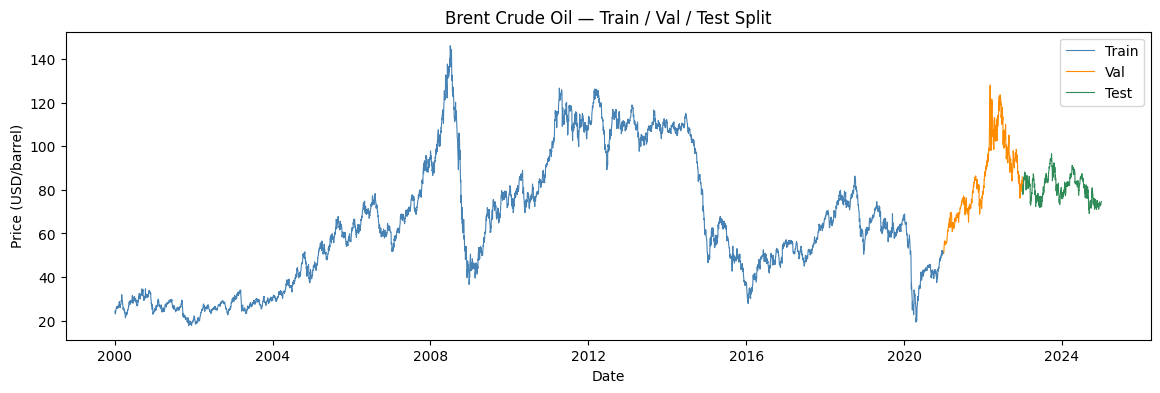

Plot saved.


In [30]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train["Price"], label="Train", color="steelblue", lw=0.8)
ax.plot(val.index,   val["Price"],   label="Val",   color="darkorange", lw=0.8)
ax.plot(test.index,  test["Price"],  label="Test",  color="seagreen",   lw=0.8)
ax.set_title("Brent Crude Oil — Train / Val / Test Split")
ax.set_ylabel("Price (USD/barrel)")
ax.set_xlabel("Date")
ax.legend()
os.makedirs("artifacts/plots", exist_ok=True)
plt.savefig("artifacts/plots/train_val_test_split.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")